# Concept Propagation Playground on VGG16_bn and ImageNet

In this notebook we built a simple utility for zennit-crp.
The main contribution is the ```run``` method which for an input shows the most relevant concepts.

In [48]:
import os

import torch
from torchvision.models.vgg import vgg16_bn
import torchvision.transforms as T
from PIL import Image
from zennit.canonizers import SequentialMergeBatchNorm
from zennit.composites import EpsilonPlusFlat

import torchvision
from crp.concepts import ChannelConcept
from crp.helper import get_layer_names
from crp.attribution import CondAttribution
from crp.visualization import FeatureVisualization
from crp.image import imgify
from tutorials.VGG16_ImageNet.download_imagenet import download


In [ ]:
device = "cuda:0" if torch.cuda.is_available() else "cpu"

model = vgg16_bn(True).to(device)
model.eval()

layer_names = get_layer_names(model, [torch.nn.Conv2d, torch.nn.Linear])

attribution = CondAttribution(model)

canonizers = [SequentialMergeBatchNorm()]
composite = EpsilonPlusFlat(canonizers)

# separate normalization from resizing for plotting purposes later
transform = T.Compose([T.Resize(256), T.CenterCrop(224), T.ToTensor()])
preprocessing =  T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

transform_norm = T.Compose([
    transform,
    preprocessing
])

data_path = "tutorials/ImageNet_data"

if data_path is None:
    # download ImageNet validation set
    data_path = "ImageNet_data"
    download(data_path)

# apply no normalization here!
imagenet_data = torchvision.datasets.ImageNet(data_path, transform=transform, split="val")

In [71]:
OUTPUT_PATH = "imagenet_output"
MODE = "SAVE" # SAVE or SHOW

In [72]:
def get_ith_last_feature_layer(i):
    # get the ith last feature layer
    return layer_names[-4 - i]

In [73]:
assert get_ith_last_feature_layer(0) == "features.40"
assert get_ith_last_feature_layer(1) == "features.37"

In [74]:
fv_path = "tutorials/VGG16_ImageNet"

def feature_visualization(concept, layer_names):
    fv = FeatureVisualization(attribution, imagenet_data, { name: concept for name in layer_names }, preprocess_fn=preprocessing, path=fv_path)
    return fv


In [75]:
softmax = torch.nn.Softmax(dim=-1)

def get_ids(sample, prob=0.05):
    y = model(sample)
    probs = softmax(y).squeeze()  # shape: (num_classes,)
    mask = probs >= prob
    selected_ids = mask.nonzero(as_tuple=True)[0]
    selected_probs = probs[selected_ids]

    # Sort by probability in descending order
    sorted_indices = torch.argsort(selected_probs, descending=True)
    sorted_ids = selected_ids[sorted_indices]
    sorted_probs = selected_probs[sorted_indices]

    return sorted_ids.tolist(), sorted_probs.tolist()


In [76]:
def get_label(id):
    return imagenet_data.classes[id]

In [77]:
def get_image(path):
    image = Image.open(path)
    sample = transform_norm(image).unsqueeze(0).to(device)

    # zennit requires gradients
    sample.requires_grad = True
    
    return image, sample

In [78]:
def get_conditions(y, channels_sequence):
    channels_names = [get_ith_last_feature_layer(i) for i in range(len(channels_sequence))]
    channels = {name: [id]  for name, id in zip(channels_names, channels_sequence)}
    conditions = {'y' : [y], **channels}

    return conditions

In [79]:
def get_top_concepts(sample, y, channels_sequence, concept_attribution, num_of_concepts):
    conditions = [get_conditions(y, channels_sequence)]
    attr = attribution(sample, conditions, composite, record_layer=layer_names)

    rel_c = concept_attribution.attribute(attr.relevances[get_ith_last_feature_layer(len(channels_sequence))], abs_norm=True)

    rel_values_tensor, concept_ids_tensor = torch.topk(rel_c[0], num_of_concepts)
    concept_ids = [int(id) for id in concept_ids_tensor]
    rel_values = [float(value) * 100 for value in rel_values_tensor]

    return concept_ids, rel_values

In [80]:
def show_top_concepts(name, sample, concept_ids,  y, channels_sequence):
    conditions =  get_conditions(y, channels_sequence)
    last_layer = get_ith_last_feature_layer(len(channels_sequence))
    new_conditions = [{**conditions, last_layer: [id]} for id in concept_ids]
    heatmap, _, _, _ = attribution(sample, new_conditions, composite)
    image = imgify(heatmap, symmetric=True, grid=(1, len(concept_ids)))

    if MODE == "SAVE":
        image.save(os.path.join(OUTPUT_PATH, name, f"concepts.png"))
    else:
        display(image)


In [81]:
def show_top_representatives(name, feature_visualization, concept_ids, layer, num_of_representatives):
    ref_c = feature_visualization.get_max_reference(concept_ids, layer, "relevance", (0, num_of_representatives), composite=composite, plot_fn=None)

    for id, images in zip(concept_ids, ref_c.values()):
        print(f"Concept {id}")
        representatives = imgify(images[0], grid=(1, num_of_representatives))
        heatmaps = imgify(images[1], symmetric=True, grid=(1, num_of_representatives))

        if MODE == "SAVE":
            representatives.save(os.path.join(OUTPUT_PATH, name, f"representatives_{id}.png"))
            heatmaps.save(os.path.join(OUTPUT_PATH, name, f"heatmaps_{id}.png"))
        else:
            display(representatives)
            display(heatmaps)

In [82]:
def run(name, sample, y, prob, channels_sequence, concept_attribution, feature_visualization, num_of_concepts, num_of_representatives):
    results = ''

    prediction_txt = f"Predicted label {get_label(y)} (id: {y}) with probability {prob}\n"
    results += prediction_txt

    if MODE == "SHOW":
        print(prediction_txt)
    
    layer = get_ith_last_feature_layer(len(channels_sequence))

    layer_txt = f'Showing layer {layer}\n'
    results += layer_txt

    if MODE == "SHOW":
        print(layer_txt)

    concept_ids, rel_values = get_top_concepts(sample, y, channels_sequence, concept_attribution, num_of_concepts)
    
    concepts_txt = f"Top {num_of_concepts} concepts are {concept_ids} with relevance {rel_values}\n"
    results += concepts_txt

    if MODE == "SHOW":
        print(concepts_txt)

    show_top_concepts(name, sample, concept_ids, y, channels_sequence)

    show_top_representatives(name, feature_visualization, concept_ids, layer, num_of_representatives)

    if MODE == "SAVE":
        with open(os.path.join(OUTPUT_PATH, name, f"results.txt"), "w") as f:
            f.write(results)

    return results



In [83]:
# Uncomment to run the feature visualization
# feature_visualization(ChannelConcept(), [get_ith_last_feature_layer(i) for i in [0, 1]]).run(composite,  0, len(imagenet_data), 32, 100)

In [84]:
concept_sum = ChannelConcept()
fv_sum = feature_visualization(concept_sum, layer_names)

In [85]:
def analyze_image(name, path):
    image, sample = get_image(path)

    display(image)

    ids, probs = get_ids(sample)

    # create folder for the image
    os.makedirs(os.path.join(OUTPUT_PATH, name), exist_ok=True)

    run(name, sample, ids[0], probs[0], [], concept_sum, fv_sum, num_of_concepts=5, num_of_representatives=8)

    # save the image
    image.save(os.path.join(OUTPUT_PATH, name))


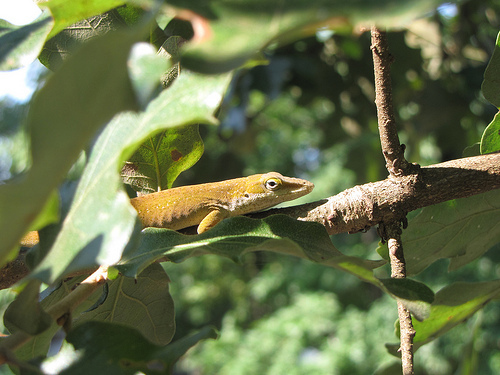

Concept 469
Concept 71
Concept 35
Concept 161
Concept 89


In [86]:
path = "tutorials/images/lizard.jpg"
name = "lizard"
analyze_image(name, path)

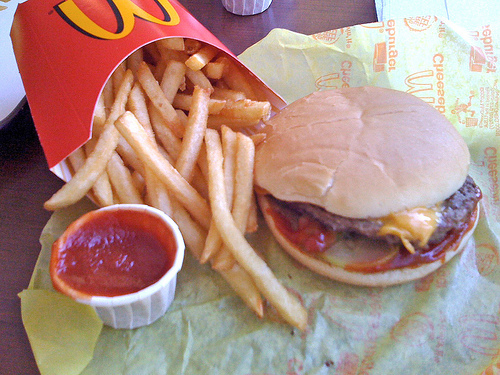

Concept 43
Concept 162
Concept 201
Concept 210
Concept 321


In [87]:
path = "tutorials/ImageNet_data/val/n07697313/ILSVRC2012_val_00008200.JPEG"
name = "cheeseburger"
analyze_image(name, path)

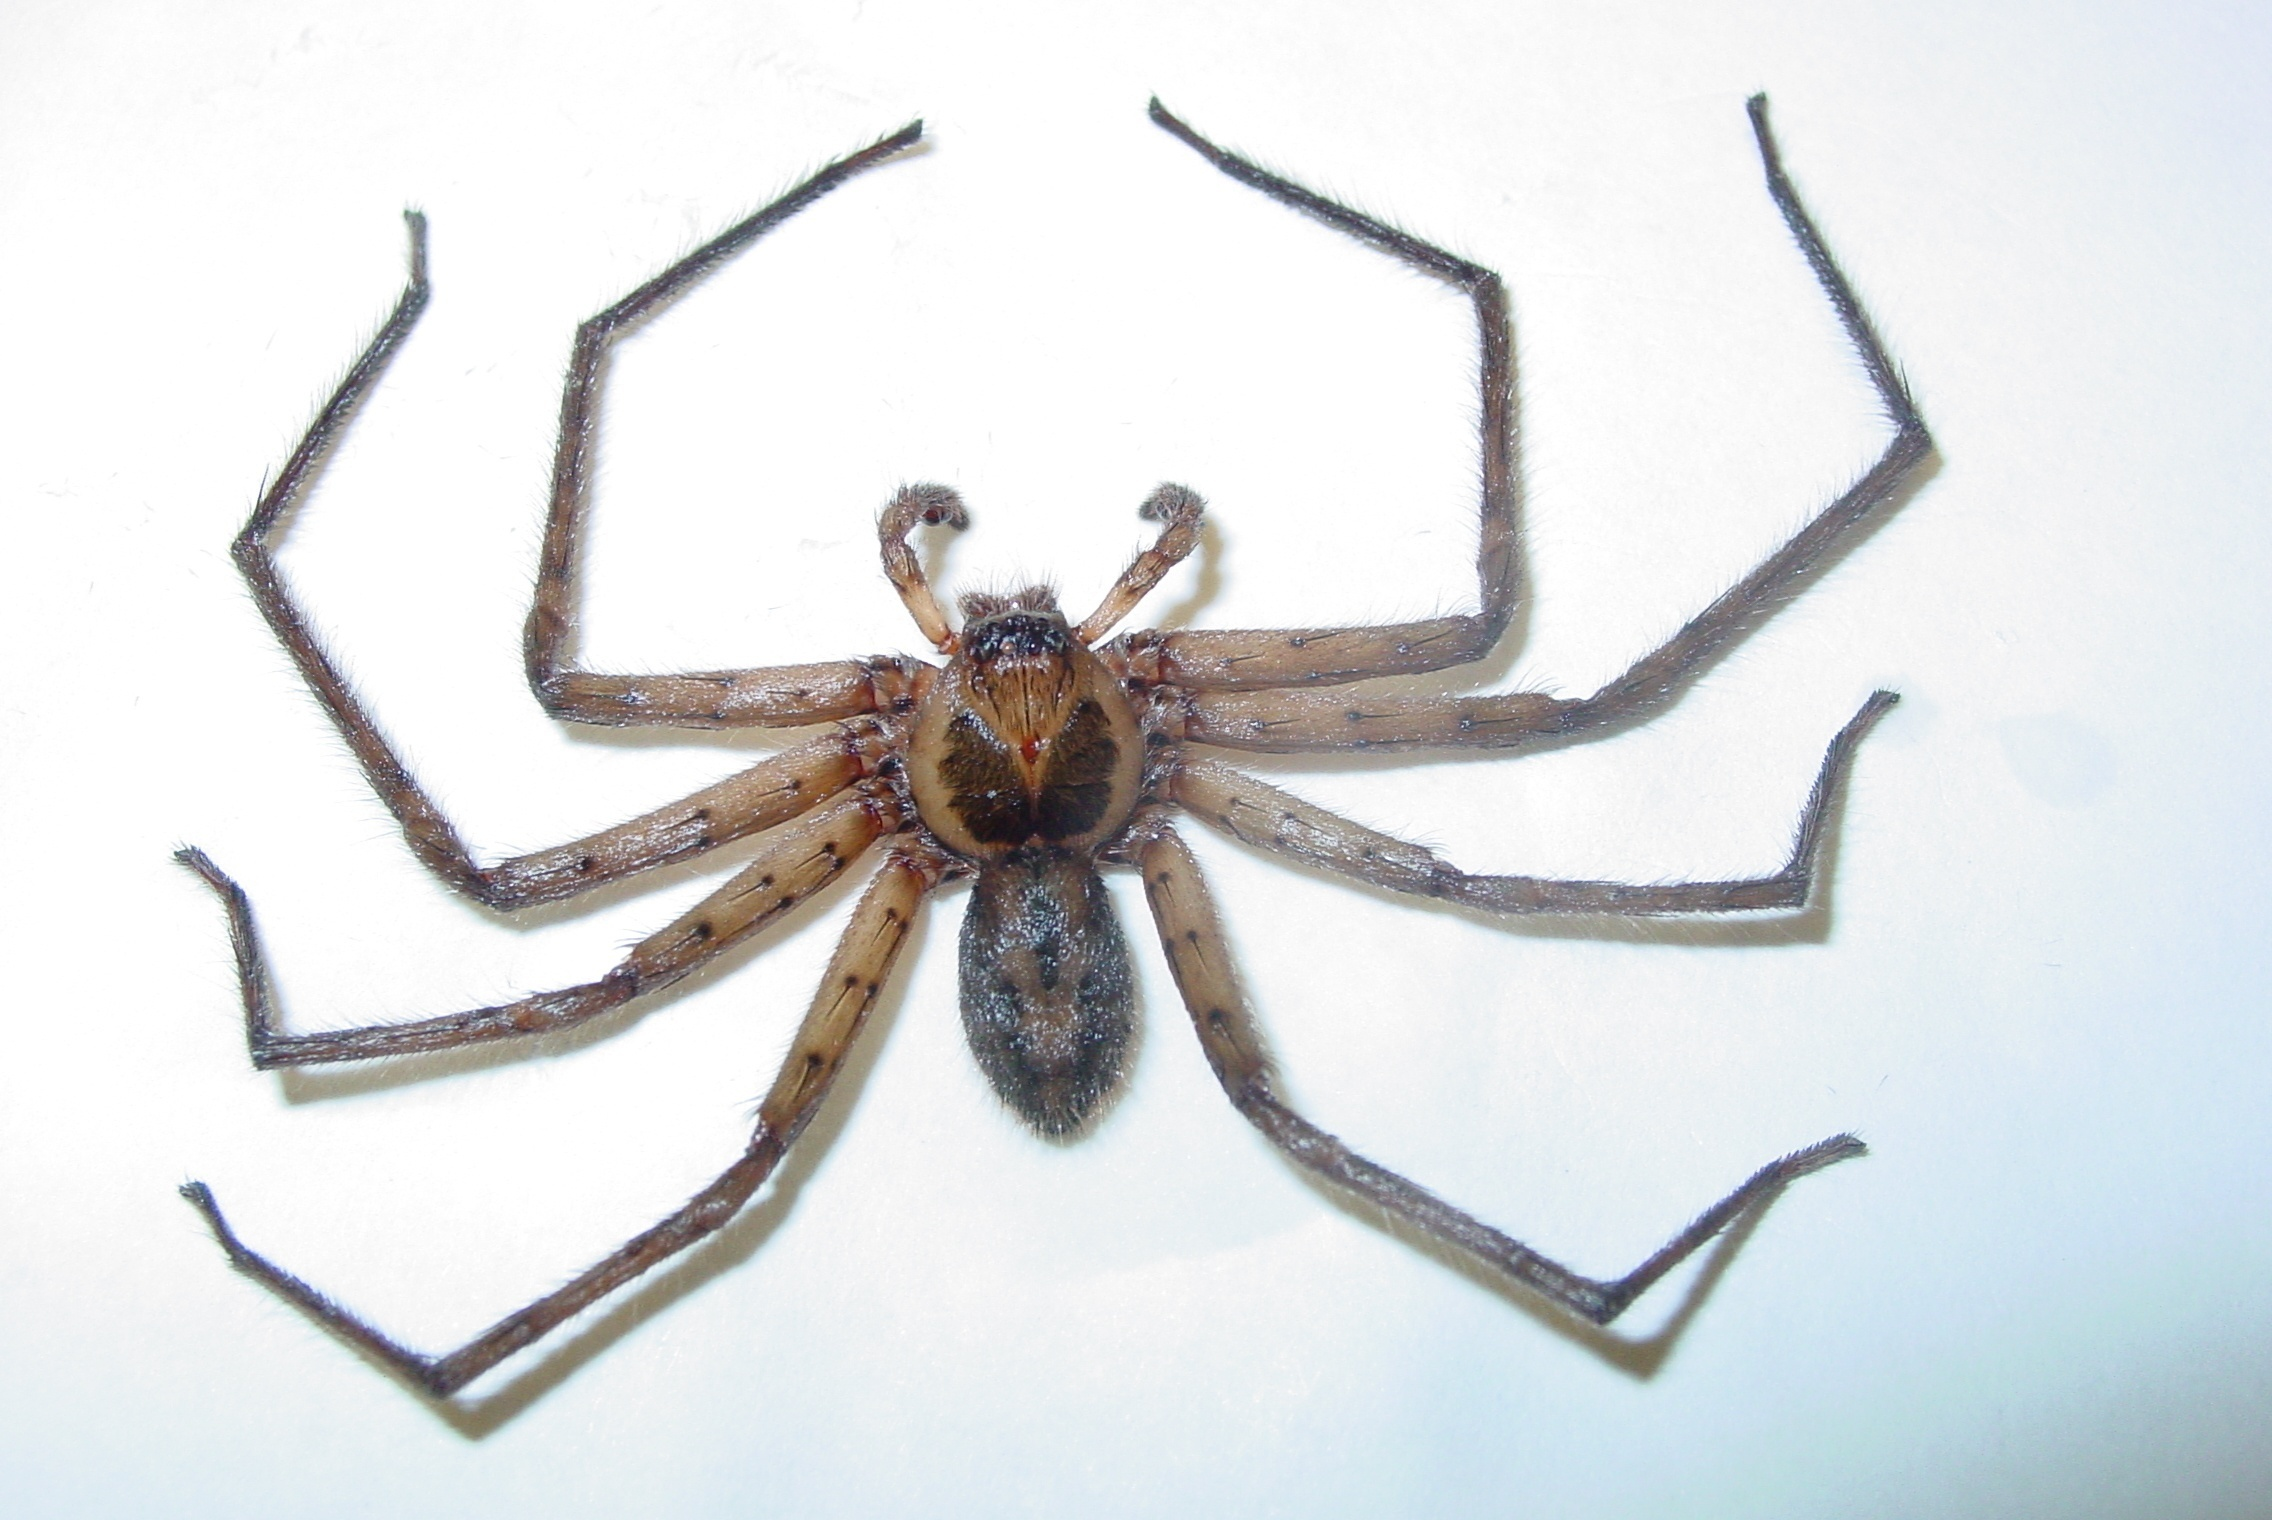

Concept 228
Concept 461
Concept 433
Concept 299
Concept 225


In [88]:
path = "tutorials/ImageNet_data/val/n01775062/ILSVRC2012_val_00005290.JPEG"
name = "spider_white_background"
analyze_image(name, path)

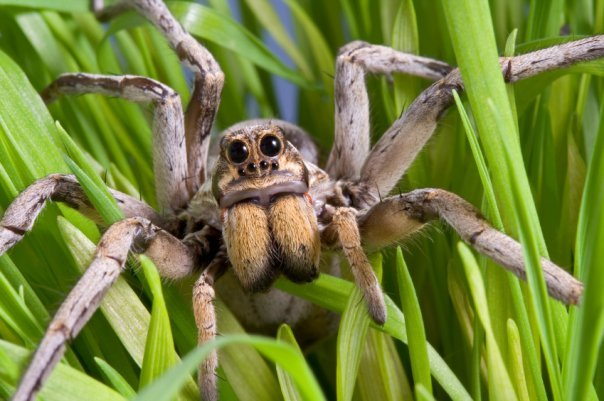

Concept 228
Concept 243
Concept 225
Concept 71
Concept 461


In [89]:
path = "tutorials/ImageNet_data/val/n01775062/ILSVRC2012_val_00040214.JPEG"
name = "spider_grass"
analyze_image(name, path)

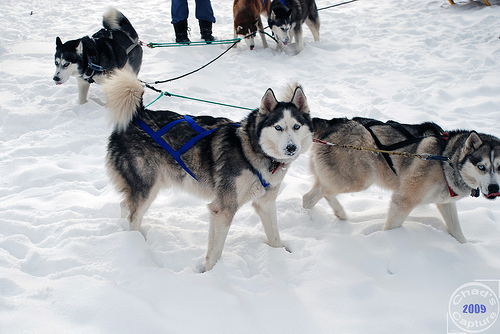

Concept 310
Concept 133
Concept 378
Concept 194
Concept 431


In [90]:
path = "tutorials/ImageNet_data/val/n03218198/ILSVRC2012_val_00049755.JPEG"
name = "dogsled_snow"
analyze_image(name, path)

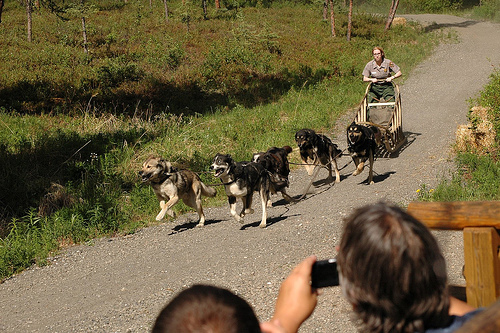

Concept 151
Concept 133
Concept 310
Concept 139
Concept 472


In [91]:
path = "tutorials/ImageNet_data/val/n03218198/ILSVRC2012_val_00043958.JPEG"
name = "dogsled_honeycomb"
analyze_image(name, path)

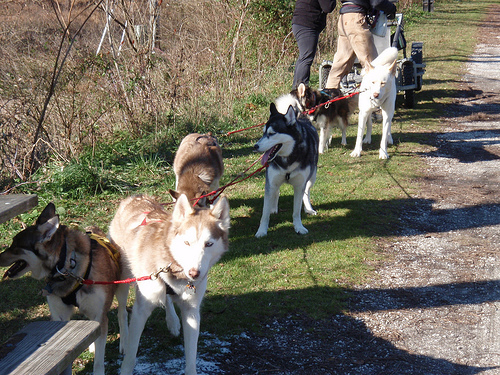

Concept 19
Concept 220
Concept 328
Concept 125
Concept 139


In [92]:
path = "tutorials/ImageNet_data/val/n03218198/ILSVRC2012_val_00007393.JPEG"
name = "dogsled_dogs"
analyze_image(name, path)